# 1. 문제 정의
- 물품 배송 예측 모델 만들기~!
- 물품 배송 데이터를 분석해서 제 시간에 물건이 배송 왔는지 예측
- 제 시간에 물건이 배송 되었는지 아닌지 '이진분류'

In [3]:
######################## 필요한 import 하기 #########################

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


import warnings
warnings.filterwarnings('ignore') 



# 2. 데이터 수집
- csv 파일

In [4]:
train = pd.read_csv('data/Train.csv')
test = pd.read_csv('data/test.csv')

# 3. 데이터 전처리

### 수치형 범수들 상관관계 시각화

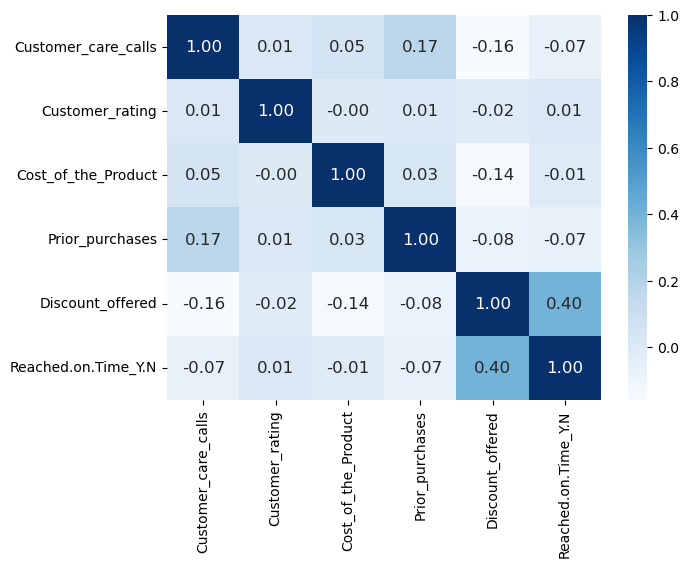

In [5]:
plt.figure(figsize=(7, 5))
sns.heatmap(data=train.corr(numeric_only=True),
           annot=True,        # annotation : 각 셀 내부 값 표시
           fmt='.2f',         # 소수 2번째자리까지 표시
           annot_kws={'size':12},  # 수치 사이즈 조절
           cmap='Blues'       # 히트맵 색상
           );

In [7]:
# ==== 컬럼 공백 제거
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

### 1) 결측치 처리 (그룹별 Median 값으로 채워넣기)

- train
    - Customer_care_calls  5423/6999 (-1576) **22%**
    - Discount_offered     3468/6999 (-3531) **50%**

- test
    - Customer_care_calls  3144/4000 (-856) **21%**
    - Prior_purchases      3633/4000 (-367) **9.2%**
    - Discount_offered     2085/4000(-1915) **48%**


In [8]:
# ======== 결측치 ===========

# 결측여부 컬럼 추가
train['Discount_missing'] = train['Discount_offered'].isnull().astype(int)
test['Discount_missing'] = test['Discount_offered'].isnull().astype(int)

median_value = train['Discount_offered'].median()

train['Discount_offered'] = train['Discount_offered'].fillna(median_value)
test['Discount_offered'] = test['Discount_offered'].fillna(median_value)

# 문의 횟수
call_median = train['Customer_care_calls'].median()

train['Customer_care_calls'] = train['Customer_care_calls'].fillna(call_median)
test['Customer_care_calls'] = test['Customer_care_calls'].fillna(call_median)

print(train['Customer_care_calls'].isnull().sum())


# 이전 구매 횟수
prior_median = train['Prior_purchases'].median()

train['Prior_purchases'] = train['Prior_purchases'].fillna(prior_median)
test['Prior_purchases'] = test['Prior_purchases'].fillna(prior_median)

print(train['Prior_purchases'].isnull().sum())


print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

0
0
0
0


### 2) 오타 제거
- Mode of shipment/Product_importance
    - 오타 수정해주고
    - ? 는 가장 많은 값으로 대체 


In [9]:
# ==== Mode_of Shipment
def clean_mode(x):
    x = x.strip() # 앞뒤 공백 제거
    x = x.replace('zk', '') # zk 제거
    if x == '?':
        return 'Ship' # 가장 많은 값인 Ship으로 대체
    return x

# Train과 Test 모두 적용
train['Mode_of_Shipment'] = train['Mode_of_Shipment'].apply(clean_mode)
test['Mode_of_Shipment'] = test['Mode_of_Shipment'].apply(clean_mode)

# 2. 이제 깔끔하게 ['Ship', 'Flight', 'Road']만
print(train['Mode_of_Shipment'].unique())
print(test['Mode_of_Shipment'].unique())





# ==== Product_importance
train['Product_importance'].unique()
# array(['low', 'medium', 'high', '?', 'mediumm', 'loww', 'highh']
train['Product_importance'].value_counts()
# low        3344
# medium     2982
# high        573
# ?            97
# mediumm       1
# loww          1
# highh         1

# 1. 오타 먼저 수정
replace_dict = {
    'loww': 'low',
    'mediumm': 'medium',
    'highh': 'high'
}

train['Product_importance'] = train['Product_importance'].replace(replace_dict)
test['Product_importance'] = test['Product_importance'].replace(replace_dict)

# 2. mode 계산 (오타 정리 후!)
mode_val = train['Product_importance'].mode()[0]

# 3. '?' → mode
train['Product_importance'] = train['Product_importance'].replace('?', mode_val)
test['Product_importance'] = test['Product_importance'].replace('?', mode_val)

print(train['Product_importance'].unique())
print(test['Product_importance'].unique())     # array(['high', 'medium', 'low']

['Ship' 'Flight' 'Road']
['Ship' 'Flight' 'Road']
['low' 'medium' 'high']
['high' 'medium' 'low']


### 3) 범주형(숫자) --> 수치형으로 변환
- Weight_in_gms
- 변환하지 못한 약 400개의 값은 median으로 채워넣기


In [10]:
# ===== Weight_in_gms

# train
train['Weight_in_gms'] = train['Weight_in_gms'].replace('?', np.nan)
train['Weight_in_gms'] = pd.to_numeric(train['Weight_in_gms'], errors='coerce')

# test
test['Weight_in_gms'] = test['Weight_in_gms'].replace('?', np.nan)
test['Weight_in_gms'] = pd.to_numeric(test['Weight_in_gms'], errors='coerce')

median_weight = train['Weight_in_gms'].median()

train['Weight_in_gms'] = train['Weight_in_gms'].fillna(median_weight)
test['Weight_in_gms'] = test['Weight_in_gms'].fillna(median_weight)

# 

### 무게에 따른 배송 현황 시각화

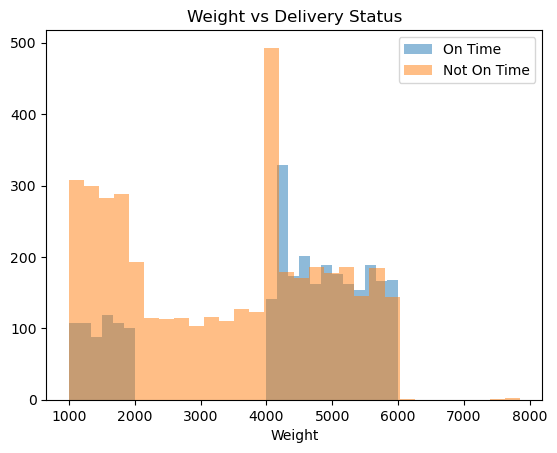

In [11]:
plt.hist(train[train['Reached.on.Time_Y.N'] == 0]['Weight_in_gms'], bins=30, alpha=0.5, label='On Time')
plt.hist(train[train['Reached.on.Time_Y.N'] == 1]['Weight_in_gms'], bins=30, alpha=0.5, label='Not On Time')

plt.legend()
plt.xlabel('Weight')
plt.title('Weight vs Delivery Status')
plt.show()

### XGB 모델 (민정)

In [ ]:
 # 2. [강력한 파생 변수 추가]
    # (1) 무게 대비 가격 (가물치 지표: 무거운데 싸면 배송이 늦어질 확률이 큼)
    df['Weight_Cost_Ratio'] = df['Weight_in_gms'] / (df['Cost_of_the_Product'] + 1)
    
    # (2) 할인율 10%의 벽 (이 데이터셋의 가장 강력한 구분선)
    df['Is_High_Discount'] = (df['Discount_offered'] > 10).astype(int)
    df['Discount_Diff_10'] = (df['Discount_offered'] - 10).abs()
    
    # (3) 고객 피로도 (전화 횟수와 이전 구매 빈도의 조합)
    df['Customer_Fatigue'] = df['Customer_care_calls'] * df['Prior_purchases']

    # 3. [노이즈 변수 제거] - 중요도가 낮아 점수를 깎아먹는 변수들
    # Gender는 분석 결과 영향력이 거의 없으므로 과감히 제거합니다.
    # ID는 이미 인덱스로 설정되어 있을 것이므로 drop 목록에 추가해도 무방합니다.
    drop_features = ['Gender']
    df = df.drop(columns=[col for col in drop_features if col in df.columns])

### 최종 코드 (기찬님)

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import warnings

warnings.filterwarnings('ignore')

train = pd.read_csv('data/Train.csv', index_col='ID')
test = pd.read_csv('data/test.csv', index_col='ID')

train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

train.replace('?', np.nan, inplace=True)
test.replace('?', np.nan, inplace=True)

for col in ['Customer_care_calls', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col] = pd.to_numeric(test[col], errors='coerce')

train['Discount_offered'] = train['Discount_offered'].fillna(train['Discount_offered'].median())
test['Discount_offered'] = test['Discount_offered'].fillna(train['Discount_offered'].median())

train['Customer_care_calls'] = train['Customer_care_calls'].fillna(train['Customer_care_calls'].median())
test['Customer_care_calls'] = test['Customer_care_calls'].fillna(train['Customer_care_calls'].median())

train['Prior_purchases'] = train['Prior_purchases'].fillna(train['Prior_purchases'].median())
test['Prior_purchases'] = test['Prior_purchases'].fillna(train['Prior_purchases'].median())

def clean_mode(x):
    if pd.isna(x): return 'Ship'
    x = str(x).strip().replace('zk', '')
    if x == '?': return 'Ship'
    return x

train['Mode_of_Shipment'] = train['Mode_of_Shipment'].apply(clean_mode)
test['Mode_of_Shipment'] = test['Mode_of_Shipment'].apply(clean_mode)

replace_dict = {'loww': 'low', 'mediumm': 'medium', 'highh': 'high', '?': 'low'}
train['Product_importance'] = train['Product_importance'].replace(replace_dict).fillna('low')
test['Product_importance'] = test['Product_importance'].replace(replace_dict).fillna('low')

train['Weight_in_gms'].fillna(train['Weight_in_gms'].median(), inplace=True)
test['Weight_in_gms'].fillna(train['Weight_in_gms'].median(), inplace=True)

train['Warehouse_block'] = train['Warehouse_block'].fillna(train['Warehouse_block'].mode()[0])
test['Warehouse_block'] = test['Warehouse_block'].fillna(train['Warehouse_block'].mode()[0])

def add_magic_features(df):
    df['Delay_Bomb'] = df['Customer_care_calls'] * df['Discount_offered']
    df['Cost_per_Weight'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] + 1)
    df['Weight_per_Discount'] = df['Weight_in_gms'] / (df['Discount_offered'] + 1)
    return df

y = train['Reached.on.Time_Y.N'].astype(int)
X = train.drop(['Reached.on.Time_Y.N'], axis=1)
X_test_submit = test.copy()

X = add_magic_features(X)
X_test_submit = add_magic_features(X_test_submit)

# 트리 모델(XGB, LGBM, CatBoost) 라벨 인코딩
cat_cols = X.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    le = LabelEncoder()
    # Train과 Test를 합쳐서 인코딩
    combined = pd.concat([X[col], X_test_submit[col]], axis=0).astype(str)
    le.fit(combined)
    X[col] = le.transform(X[col].astype(str))
    X_test_submit[col] = le.transform(X_test_submit[col].astype(str))

print("4. 🚀 3대장 AI(XGB + LGBM + CatBoost) 소환 및 5-Fold 학습 시작...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probs = np.zeros(len(X))
test_probs = np.zeros(len(X_test_submit))

# 3개의 최고급 모델 셋팅
xgb_params = {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.05, 'random_state': 42, 'eval_metric': 'logloss'}
lgbm_params = {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'random_state': 42, 'verbose': -1}
cat_params = {'iterations': 150, 'depth': 6, 'learning_rate': 0.05, 'random_state': 42, 'verbose': 0}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # 1. XGBoost
    xgb = XGBClassifier(**xgb_params)
    xgb.fit(X_tr, y_tr)
    xgb_pred = xgb.predict_proba(X_va)[:, 1]
    
    # 2. LightGBM
    lgb = LGBMClassifier(**lgbm_params)
    lgb.fit(X_tr, y_tr)
    lgb_pred = lgb.predict_proba(X_va)[:, 1]
    
    # 3. CatBoost (범주형 데이터의 최강자)
    cat = CatBoostClassifier(**cat_params)
    cat.fit(X_tr, y_tr)
    cat_pred = cat.predict_proba(X_va)[:, 1]
    
    # 3개 모델의 예측 확률을 평균 내기 (소프트 보팅 앙상블)
    oof_probs[val_idx] = (xgb_pred + lgb_pred + cat_pred) / 3
    
    # 테스트 데이터 예측 누적
    test_probs += (xgb.predict_proba(X_test_submit)[:, 1] + 
                   lgb.predict_proba(X_test_submit)[:, 1] + 
                   cat.predict_proba(X_test_submit)[:, 1]) / 3 / 5

best_acc = 0
best_t = 0.5

# 40% ~ 60% 사이에서 가장 정답률이 높은 커트라인을 찾습니다.
for t in np.arange(0.40, 0.61, 0.01):
    temp_preds = (oof_probs > t).astype(int)
    
    rule_mask = (X['Discount_offered'] > 10) | ((X['Weight_in_gms'] >= 2000) & (X['Weight_in_gms'] <= 4000))
    temp_preds[rule_mask] = 1
    
    score = accuracy_score(y, temp_preds)
    if score > best_acc:
        best_acc = score
        best_t = t


# ==========================================
# 6. 실제 제출 파일 생성 (테스트 데이터도 동일하게 적용)
# ==========================================
final_submit = (test_probs > best_t).astype(int)

# 테스트 데이터에도 절대 법칙 덮어쓰기
test_rule_mask = (test['Discount_offered'] > 10) | ((test['Weight_in_gms'] >= 2000) & (test['Weight_in_gms'] <= 4000))
final_submit[test_rule_mask] = 1

pd.DataFrame({'ID': test.index, 'Reached.on.Time_Y.N': final_submit}).to_csv('Ultimate_70_Master_Submission.csv', index=False)